## Stationarity & Detrending Strategies

**What is stationarity?**

Stationarity is a fundamental concept in time series analysis that refers to the statistical properties of a time series being constant over time. A stationary time series has a constant mean, variance, and autocorrelation structure, which allows for more reliable modeling and forecasting. Non-stationary time series, on the other hand, exhibit trends, seasonality, or changing variance, making them more challenging to model accurately.

**Why is stationarity important?**

Many forecasting models, especially traditional statistical models like ARIMA and Machine Learning Regressors, assume that the underlying time series is stationary. If the data is non-stationary, these models may produce biased or inaccurate forecasts. By ensuring stationarity through techniques like differencing and detrending, we can improve the performance of these models and obtain more reliable forecasts.

The time series below is non-stationary, with an upward trend and weekly seasonality. We will use this time series to demonstrate how to apply different forecasting models, such as ETS, ARIMA, and Machine Learning models.

In [ ]:
#| hide
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"

# dont show warnings
import warnings
warnings.filterwarnings("ignore")

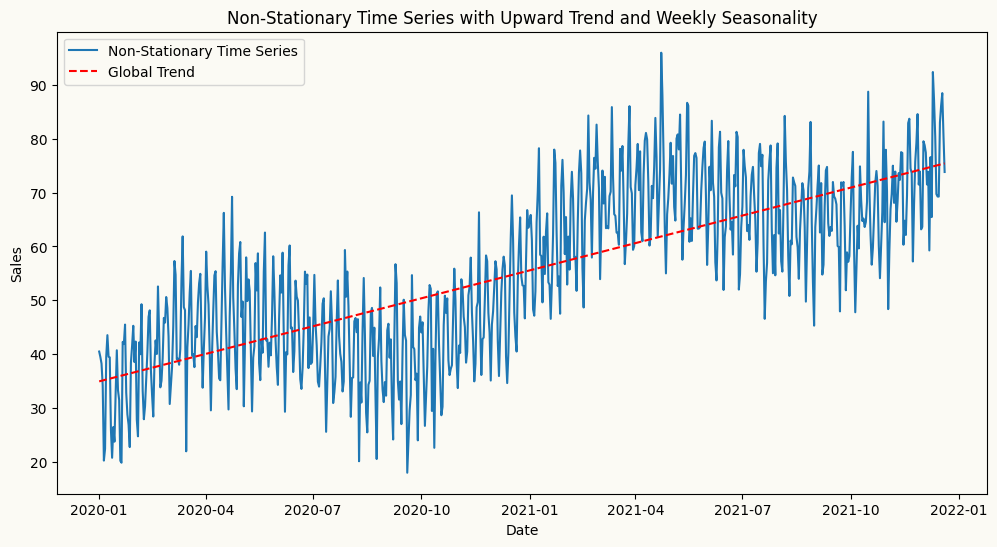

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
np.random.seed(42)
data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])

# plot trend line using linear regression
from sklearn.linear_model import LinearRegression
X = np.arange(len(sales_data)).reshape(-1, 1)
y = sales_data['sales'].values
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)


plt.figure(figsize=(12, 6))
plt.plot(sales_data.index, sales_data['sales'], label='Non-Stationary Time Series')
plt.plot(sales_data.index, trend_line, label='Global Trend', color='red', linestyle='--')
plt.title('Non-Stationary Time Series with Upward Trend and Weekly Seasonality')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
#| hide

## Create and ARIMA(2,1,1) time series
from statsmodels.tsa.arima_process import ArmaProcess
arparams = np.array([.75, -.25])
maparams = np.array([.65, .35])
ar = np.r_[1, -arparams] # add zero-lag and negate
ma = np.r_[1, maparams] # add zero-lag
arma_process = ArmaProcess(ar, ma)
arma_data = arma_process.generate_sample(nsample=720)
arma_data = np.cumsum(arma_data)  # Integrate to make it ARIMA(2,1,1)
arma_data += 30 + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 1, 720)  # Add trend and seasonality
arma_sales_data = pd.DataFrame(arma_data, index=date_range, columns=['Value'])

Here, we forecast the same series using multiple models — starting with ETS, which handles non-stationary data natively, then ARIMA and ML regressors, where peshbeen's built-in detrending and transformation pipeline takes care of stationarity automatically.

**ETS Example**

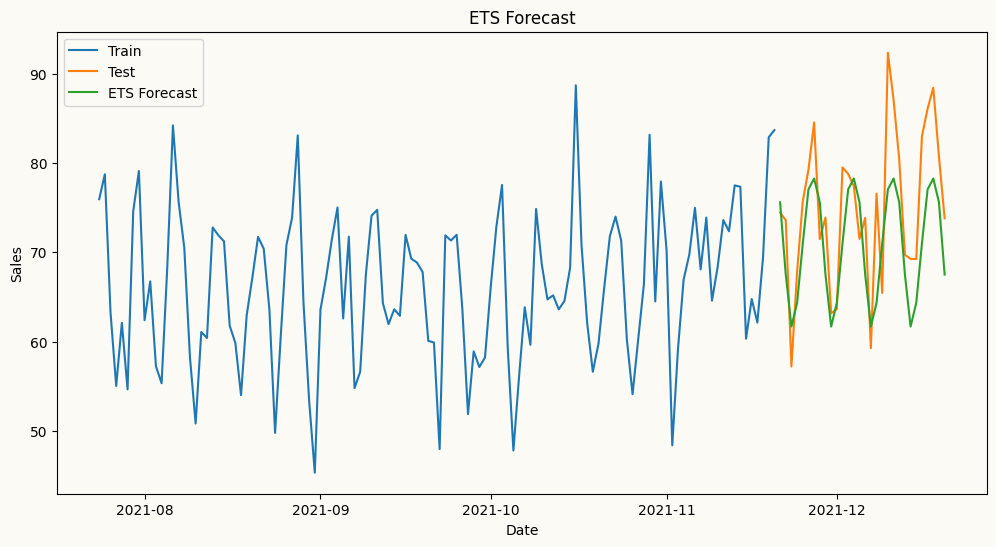

In [ ]:

from lightgbm import LGBMRegressor
train = sales_data.iloc[:-30]
test = sales_data.iloc[-30:]
from peshbeen.models import ets, arima, ml_forecaster
ets_model = ets(target_col='sales', seasonal = 'additive', seasonal_periods=7)
ets_model.fit(train)
ets_forecast = ets_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, ets_forecast, label='ETS Forecast')
plt.title('ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

**ARIMA Example**

Arima automatically applies differencing to make the series stationary by specifying the order of differencing (d) in the model parameters. In this example, we set d=1 to apply first-order differencing, which helps to remove the trend and make the series stationary for ARIMA modeling. To guide lag selection, we can also visualize the ACF and PACF plots of the original series to identify the ideal number of autoregressive (p) and moving average (q) terms for the ARIMA model. The ACF plot helps to identify the number of MA terms, while the PACF plot helps to identify the number of AR terms. As shown in the plots below, the ACF plot exhibits a slow decay, indicating non-stationarity, while the PACF plot shows significant spikes at lags 1 and 2, suggesting that an AR(2) model may be appropriate for the ARIMA model.

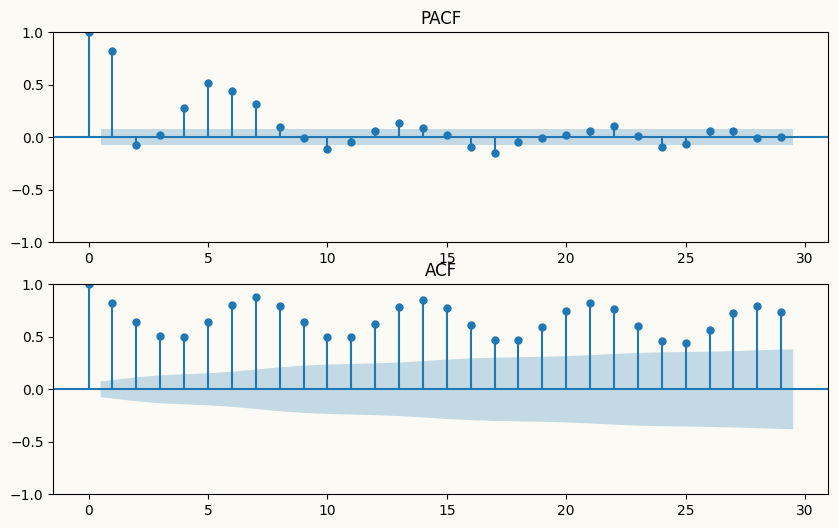

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_pacf(train["sales"], ax=axes[0], title="PACF")
plot_acf(train["sales"], ax=axes[1], title="ACF")
plt.show()

### Trend removal via differencing

Let's see how the forecasts look when doesn't apply differencing for ARIMA and machine learning forecasters using LightGBMRegressor as regressor.

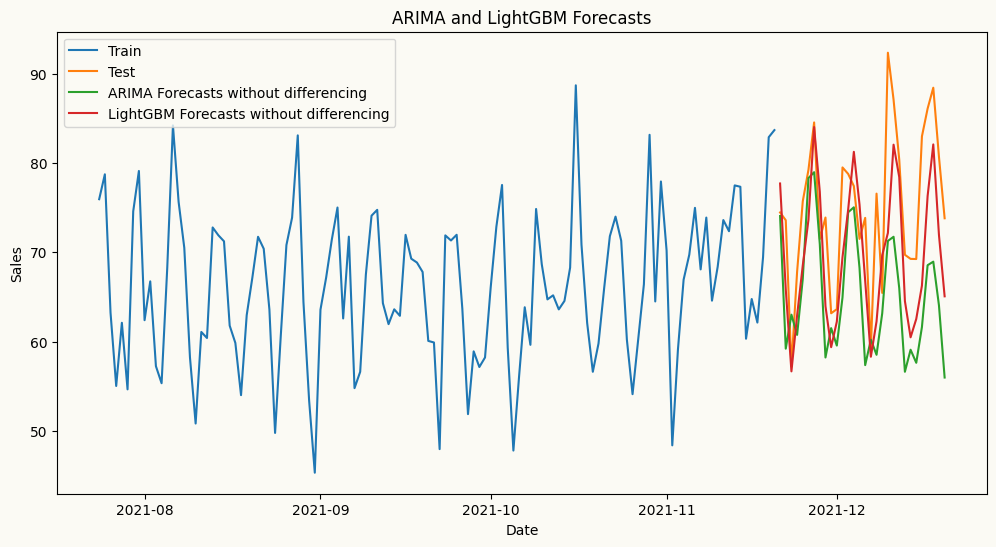

In [ ]:
# arima forecast
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1),
                          lags=7)
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecasts without differencing')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecasts without differencing')
plt.title('ARIMA and LightGBM Forecasts')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

As shown in the plot above, particularly, forecasts from the ARIMA model without differencing are underforecasting the upward trend in the data, resulting in forecasts that are significantly lower than the actual values. This highlights the importance of applying differencing to achieve stationarity when using ARIMA models, as it allows the model to capture the underlying patterns and trends in the data more effectively, leading to more accurate forecasts. Now, let's see how the forecasts look when we apply differencing for ARIMA.

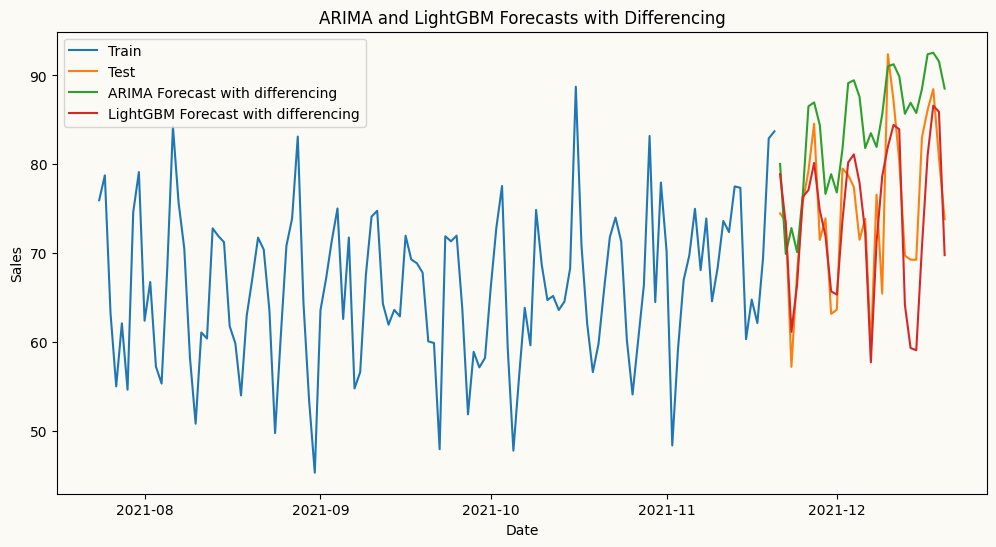

In [ ]:
# arima forecast
arima_model = arima(target_col='sales', order=(2,1,0), seasonal_order=(1,0,0), seasonal_length=7)
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, difference=1)
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)
# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast with differencing')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast with differencing')
plt.title('ARIMA and LightGBM Forecasts with Differencing')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

When differencing is applied to strongly trending data, results can vary significantly across model families. LightGBM manages to track the trend reasonably well, while ARIMA overshoots considerably — because differencing removes the trend incrementally, and in the presence of a strong deterministic trend, this can inflate the model's variance and cause it to fit noise rather than signal, leading to poor out-of-sample performance.

This highlights an important practical consideration: differencing is not always the right tool for non-stationarity. When the trend is strong and smooth, more effective alternatives include detrending via linear regression, or piecewise linear regression when structural breaks are present. When the data also exhibits local seasonality or a time-varying trend, a better approach is to first fit an ETS model to capture those components, then apply ARIMA to the residuals.

### Trend removal via global detrending

Rather than differencing, we can detrend the series by fitting a linear regression to the original time series, extracting the underlying trend, and passing the residuals to ARIMA or ML regressors. This is a valid and often more stable approach to achieving stationarity when the trend is deterministic and approximately linear — the residuals are stationary by construction, and the forecasting model focuses purely on the remaining dynamics. peshbeen's detrending pipeline handles this automatically.

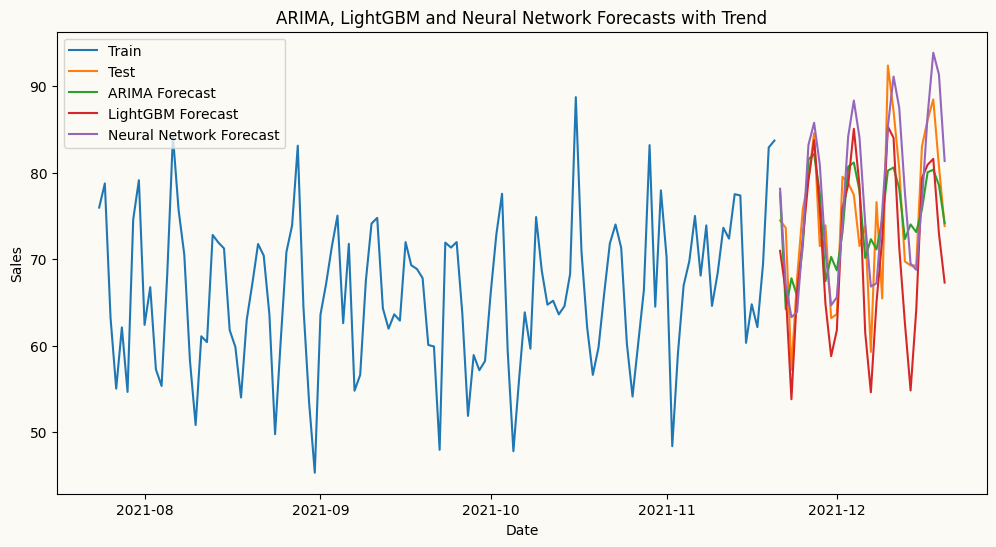

In [ ]:
# arima forecast with linear detrending
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7, trend='linear')
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm with linear detrending
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100, learning_rate=0.1), lags=7, trend='linear')
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# ml forecast using neural network with linear detrending
from sklearn.neural_network import MLPRegressor
nn_model = ml_forecaster(target_col='sales',model=MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', max_iter=200), lags=7, trend='linear')
nn_model.fit(train)
nn_forecast = nn_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.plot(test.index, nn_forecast, label='Neural Network Forecast')
plt.title('ARIMA, LightGBM and Neural Network Forecasts with Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In the plot above, we can see that the forecasts from the ARIMA, LightGBM and Neural Network models with detrending are much closer to the actual values and more unbiased compared to the forecasts without detrending. This demonstrates the effectiveness of detrending in improving the accuracy of forecasts from ARIMA and machine learning models when dealing with non-stationary time series data. By removing the underlying trend, the models can better capture the true patterns in the data, leading to more accurate and reliable forecasts.

### Trend removal via ETS (Error-Trend-Seasonality)

The trend may not always be linear, and the series may also exhibit a time-varying trend. In such cases, a more effective approach is to first fit an ETS model to capture the trend (or together with the seasonal component), then apply ARIMA or ML regressors to the residuals. This allows us to model the complex non-stationarity in the data more effectively, as the ETS model can capture the evolving trend and seasonal patterns, while the ARIMA or ML model focuses on modeling the remaining stationary residuals. peshbeen's pipeline automates this process, ensuring that the forecasting models are applied to stationary data for improved accuracy.

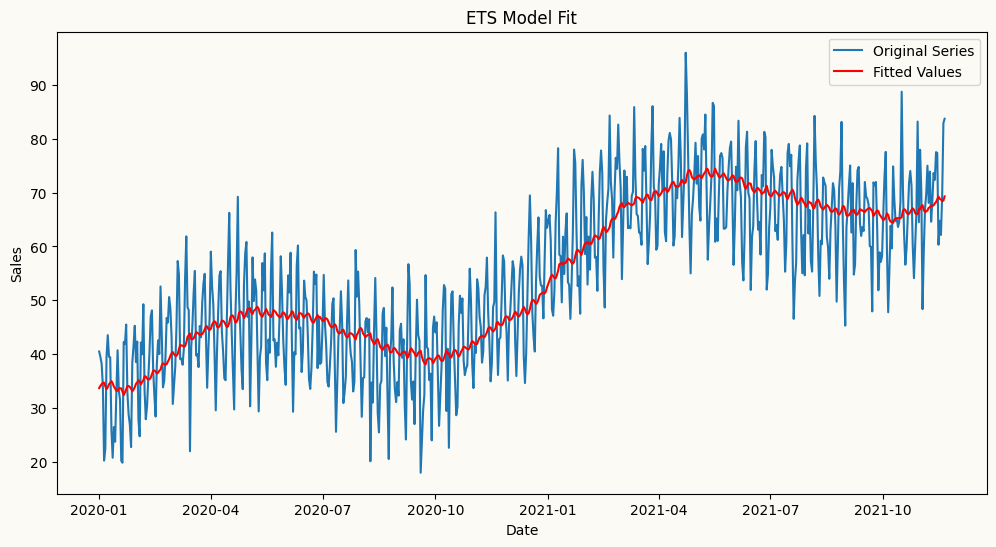

In [ ]:
# We might need to use a more flexible trend model like ETS to capture the non-linear trend in the data. Let's fit an ETS model and plot the fitted values.
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets_model = ExponentialSmoothing(train['sales'], trend='add')
ets_model_fit = ets_model.fit(smoothing_level=0.05, smoothing_trend=0.001)
# plot the fitted values and the original series
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['sales'], label='Original Series')
plt.plot(train.index, ets_model_fit.fittedvalues, label='Fitted Values', color='red', linestyle='-')
plt.title('ETS Model Fit')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

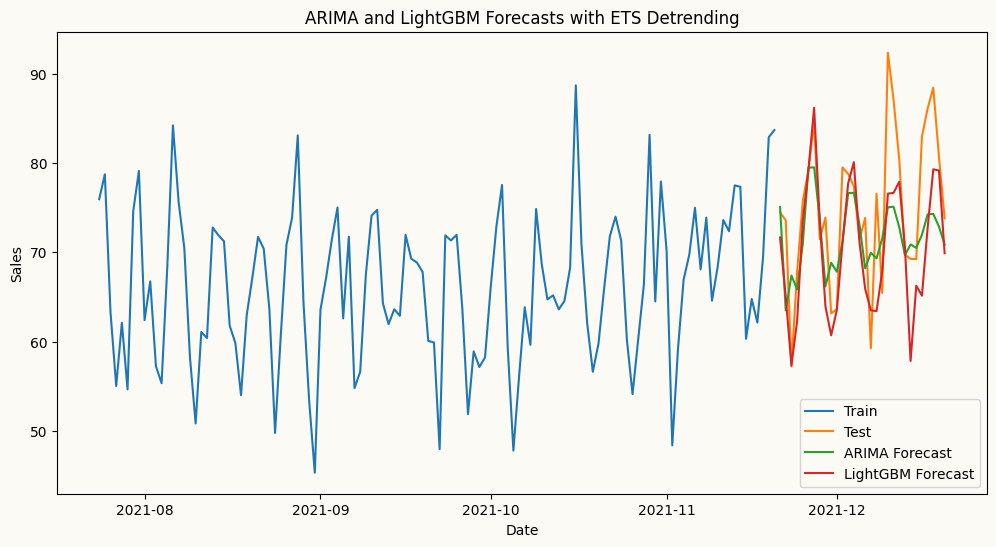

In [ ]:
# arima forecast with ets detrending
arima_model = arima(target_col='sales', order=(2,0,0), seasonal_order=(1,0,0), seasonal_length=7,
                    trend='ets', ets_params={'trend': 'add','smoothing_level': 0.05, 'smoothing_trend': 0.001})
arima_model.fit(train)
arima_forecast = arima_model.forecast(H=30)

# ml forecast using lightgbm with ets detrending
lgb_model = ml_forecaster(target_col='sales',model=LGBMRegressor(verbose=-1, n_estimators=100,learning_rate=0.1),
                          lags=7, trend='ets', ets_params={'trend': 'add', 'smoothing_level': 0.05, 'smoothing_trend': 0.001})
lgb_model.fit(train)
lgb_forecast = lgb_model.forecast(H=30)

# plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, lgb_forecast, label='LightGBM Forecast')
plt.title('ARIMA and LightGBM Forecasts with ETS Detrending')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

### Trend removal via Piecewise Linear Regression

Linear detrending assumes a single consistent trend across the entire series — but what if the trend shifts at some point? In such cases, piecewise linear regression is a more appropriate approach: given a known breakpoint, it fits separate linear trends to each segment. peshbeen's detrending pipeline supports this automatically, allowing both statistical and ML models to benefit from more accurate trend removal in the presence of structural breaks.

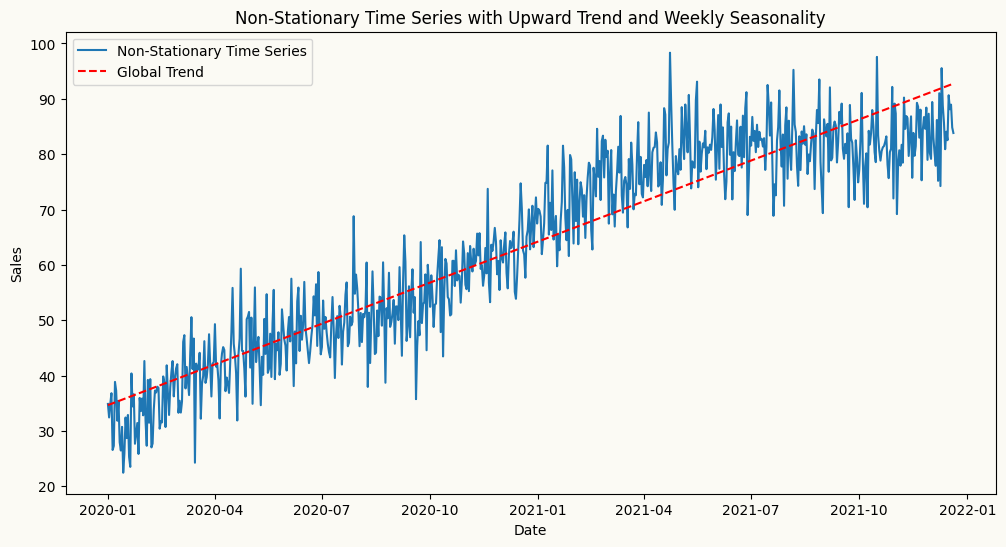

In [ ]:
#| hide

date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
np.random.seed(42)

doy = date_range.dayofyear.to_numpy()  # force NumPy, not pandas Index

data = (
    30
    + 0.1 * np.arange(720)
    + 3 * np.sin(2 * np.pi * doy / 7)
    + 3 * np.sin(2 * np.pi * doy / 365)
    + np.random.normal(0, 5, 720)
)

# now mutable
data[520:] -= 0.08* np.arange(200)

sales_struct_ch = pd.DataFrame(data, index=date_range, columns=['sales'])

from sklearn.linear_model import LinearRegression
X = np.arange(len(sales_struct_ch)).reshape(-1, 1)
y = sales_struct_ch['sales'].values
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(sales_struct_ch.index, sales_struct_ch['sales'], label='Non-Stationary Time Series')
plt.plot(sales_struct_ch.index, trend_line, label='Global Trend', color='red', linestyle='--')
plt.title('Non-Stationary Time Series with Upward Trend and Weekly Seasonality')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

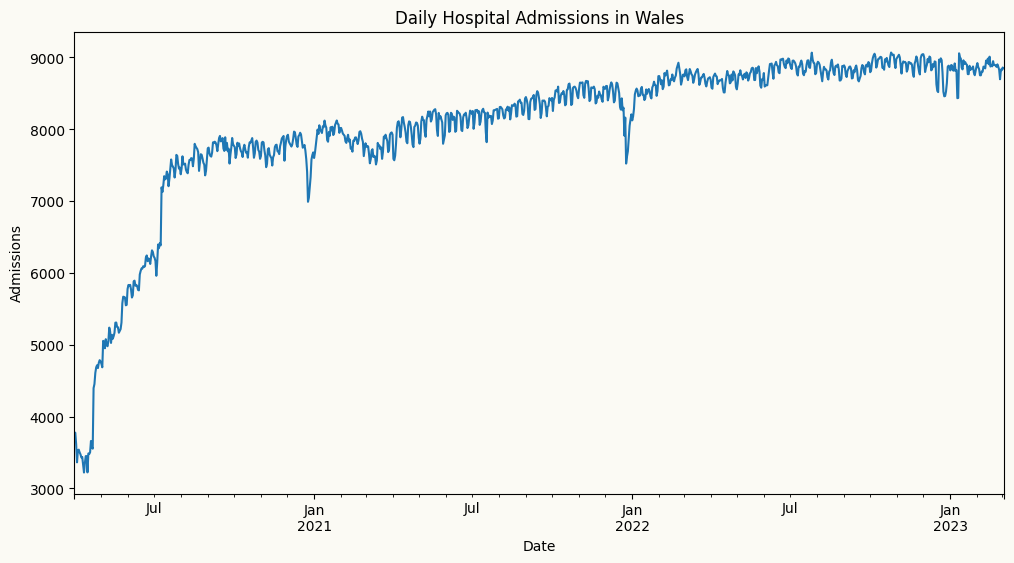

In [ ]:
# lets explore the noisy wales hospital admissions dataset to see how piecewise linear regression can help with structural breaks in the trend. The dataset contains daily hospital admissions in Wales, and we know there was a significant structural break in the trend around March 2020 due to the COVID-19 pandemic. We will load the dataset and visualize the trend to identify the breakpoint.
from peshbeen.datasets import load_wales_admissions
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
cat_variables = ["day_of_week", "month"]
figure, ax = plt.subplots(figsize=(12,6))
load_wales_admissions["admissions"].plot(ax=ax)
ax.set_title("Daily Hospital Admissions in Wales")
ax.set_xlabel("Date")
ax.set_ylabel("Admissions")
plt.show()

Let's find the breakpoint using the pelt method from the `ruptures` library and `radial basis function` cost function, which is good for detecting changes in mean and variance.

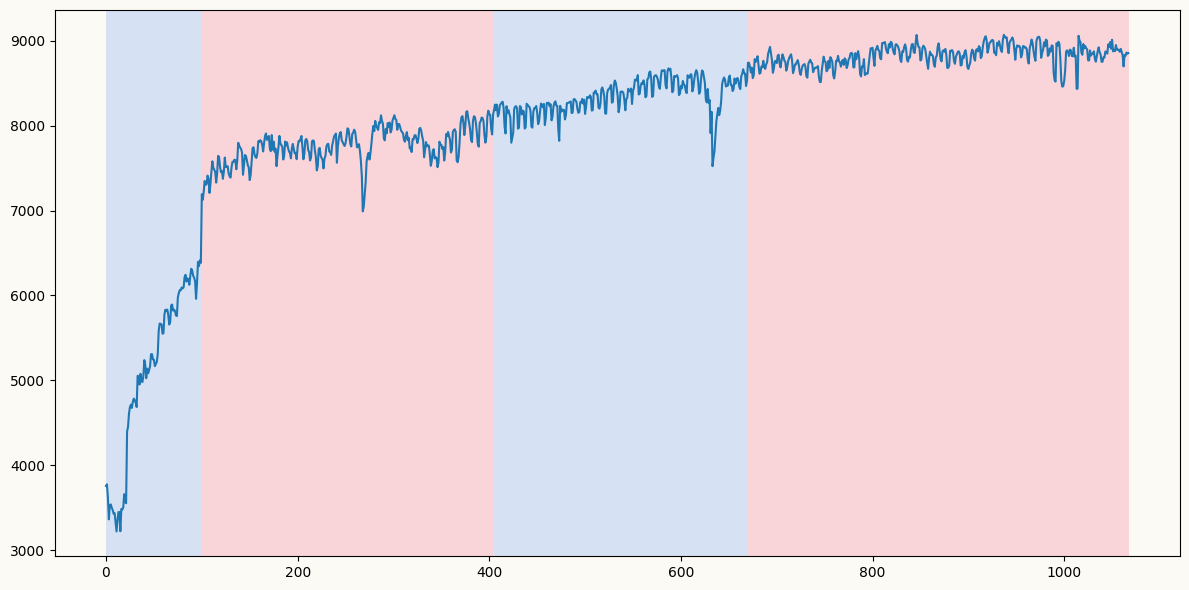

In [ ]:
import ruptures as rpt
admis_array = load_wales_admissions["admissions"].values
change_det = rpt.Pelt(model="rbf").fit(admis_array)
result_rbf = change_det.predict(60) # higher penalty means fewer breakpoints, recommend trying other values to see which one captures the break better visually.
rpt.display(admis_array, result_rbf, figsize=(12, 6))
plt.show()

In [ ]:
result_rbf # the detected breakpoints seem to be at indices 100 and 510 (the last one is at the end of the series, so we can ignore it)

[100, 405, 670, 1068]

Although change point detection methods suugest 2 breakpoints, it seems that the first one is more prevalent from the plot, which is around July 2020, when the relaxation of the first COVID-19 lockdown measures started in UK. By specifying this breakpoint in peshbeen's detrending pipeline, we can fit separate linear trends before and after the breakpoint, allowing for more accurate modeling of the underlying trend in the presence of structural breaks. This approach helps to capture the different dynamics in each segment of the series, leading to improved forecasting performance for both statistical and machine learning models.

First, we can visualize the original series along with the fitted piecewise linear trend to confirm that the breakpoint is correctly identified and that the piecewise linear regression captures the underlying trend effectively.

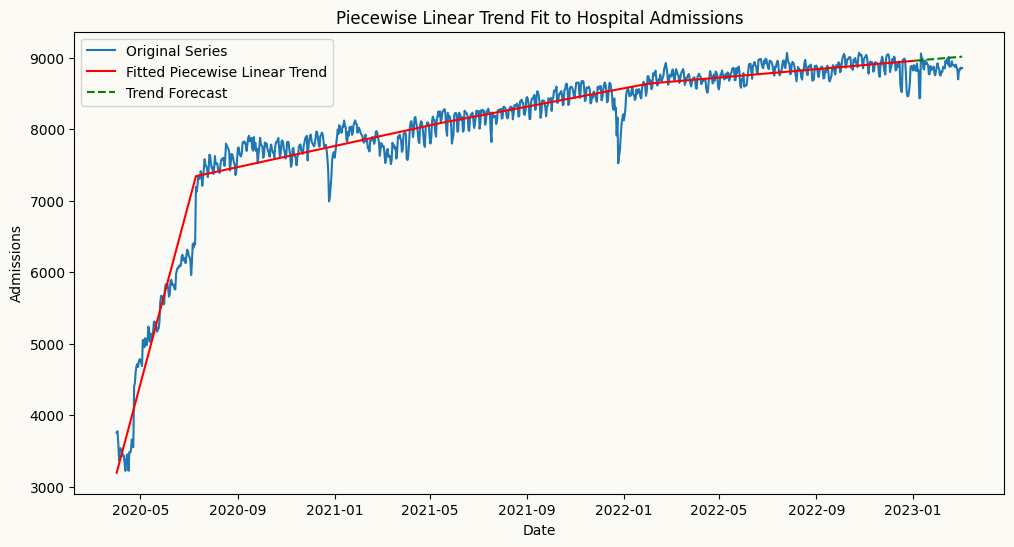

In [ ]:
from peshbeen.statstools import lr_trend_model, forecast_trend
ch_points = result_rbf[:-1] # ignore the last breakpoint at the end of the series
train_admit_trend = load_wales_admissions.iloc[:-60]
test_admit_trend = load_wales_admissions.iloc[-60:]
fitted_trend, pw_model, _ = lr_trend_model(train_admit_trend["admissions"], breakpoints=ch_points, type="piecewise")
trend_forecast, _ = forecast_trend(model=pw_model, H=60, breakpoints=ch_points, start=train_admit_trend.shape[0])

# plot the original series and the fitted piecewise linear trend
plt.figure(figsize=(12, 6))
plt.plot(load_wales_admissions.index, load_wales_admissions['admissions'], label='Original Series')
plt.plot(load_wales_admissions.index[:-60], fitted_trend, label='Fitted Piecewise Linear Trend', color='red', linestyle='-')
plt.plot(test_admit_trend.index, trend_forecast, label='Trend Forecast', color='green', linestyle='--')
plt.title('Piecewise Linear Trend Fit to Hospital Admissions')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.legend()
plt.show()

The plot above shows the original non-stationary time series with an upward trend with breaks, along with the fitted piecewise linear trend (in red) that captures the structural break around July 2020. This visualization confirms that the piecewise linear regression is effectively modeling the changing trend in the data, allowing for more accurate detrending and improved forecasting performance for a model such as LGBMRegressor that is applied to the detrended series.

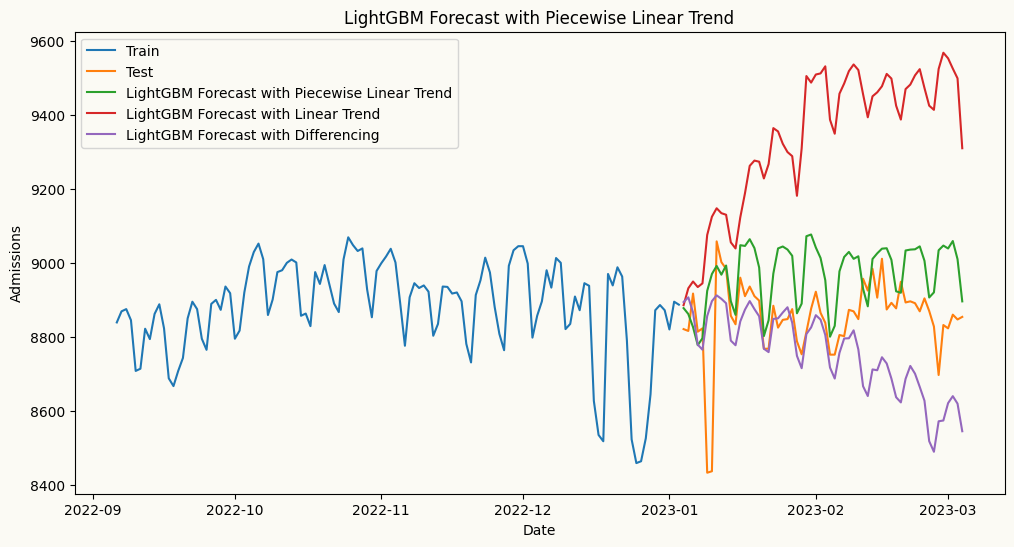

In [ ]:
# forecasting model incorporating piecewise linear trend
pw_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, trend="linear", change_points=ch_points) 
pw_fmodel.fit(train_admit_trend)
pw_forecasts = pw_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# forecasting model incorporating piecewise linear trend
lr_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, trend="linear")
lr_fmodel.fit(train_admit_trend)
lr_forecasts = lr_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# Forecast using differencing to remove the trend
diff_fmodel = ml_forecaster(model=LGBMRegressor(),
              target_col='admissions', lags = 7, cat_variables=cat_variables, difference=1)
diff_fmodel.fit(train_admit_trend)
diff_forecasts = diff_fmodel.forecast(H=60, exog=test_admit_trend[cat_variables])

# plot the forecast and actuals
plt.figure(figsize=(12, 6))
plt.plot(train_admit_trend.index[-120:], train_admit_trend['admissions'][-120:], label='Train')
plt.plot(test_admit_trend.index, test_admit_trend['admissions'], label='Test')
plt.plot(test_admit_trend.index, pw_forecasts, label='LightGBM Forecast with Piecewise Linear Trend')
plt.plot(test_admit_trend.index, lr_forecasts, label='LightGBM Forecast with Linear Trend')
plt.plot(test_admit_trend.index, diff_forecasts, label='LightGBM Forecast with Differencing')
plt.title('LightGBM Forecast with Piecewise Linear Trend')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.legend()
plt.show()

From the plot above, we can see that the piecewise linear regression captures the future trend more accurately than both the global linear trend and differencing. The piecewise linear trend (in green) closely follows future values of the series, while the global linear trend (in red) overestimates the future trend, and the differenced series (in purple) underestimates it. This highlights the importance of using piecewise linear regression for detrending when there are structural breaks in the data, as it allows for more accurate modeling of the underlying trend and improved forecasting performance.